# CE 1110 · Tarea 1 — Generación y caracterización de señales

Se generan **tres casos reproducibles** (señal limpia, ruido y señal contaminada) y se caracterizan según los puntos a) – e). En esta sección **no se aplica ningún filtrado**.

| Caso | Señal útil | Contaminación |
|---|---|---|
| 1 | Multitono | Interferencia sinusoidal separada de las componentes útiles |
| 2 | Multitono | Ruido blanco |
| 3 | Multitono | Ruido de banda limitada que se superpone parcialmente con la banda útil |

Ejecutar desde la raíz `tarea1_grupoXX/`. Salidas: `pruebas/caso_k/` (3 WAV por caso), `resultados/metricas.csv`, `resultados/figuras/` y `metadatos/configuraciones.json`.

> Al reproducir los WAV use volumen bajo.

In [2]:
import json, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt, chirp, get_window, welch   # butter/sosfiltfilt: solo para generar el ruido de banda limitada
from scipy.stats import kurtosis

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)

## 1. Configuración
Única celda de parámetros. Cada caso tiene una semilla distinta.

In [ ]:
GRUPO = 'XX'
RAIZ  = Path('.')

DIR_SRC        = RAIZ / 'src'
DIR_PRUEBAS    = RAIZ / 'pruebas'
DIR_RESULTADOS = RAIZ / 'resultados'
DIR_FIGURAS    = DIR_RESULTADOS / 'figuras'
DIR_METADATOS  = RAIZ / 'metadatos'

FS          = 16_000     # Hz
DURACION    = 6.0        # s  -> N = 96 000
PICO_MAXIMO = 0.80       # ganancia común a los 3 archivos de cada caso
FADE_MS     = 20
TOL_SNR_DB  = 0.01       # solo se admite redondeo
ANCHO_BANDA_HZ    = 500  # bandas para la distribución de energía
MARGEN_BANDA_UTIL = 100  # Hz alrededor de las frecuencias útiles
ANCHO_LOCAL_HZ    = 5.0  # semiancho de la ventana para el análisis local por tono

BASE = dict(tipo_senal='multitono', frecuencias=[440, 880, 1320], amplitudes=[1.0, 0.55, 0.30],
            fases=[0, 35, -50], f_interferencia=2500, banda_ruido=(2500, 3800), num_impulsos=10)
CASOS = {
    1: dict(BASE, nombre='caso_1', semilla=20261101, tipo_ruido='tonal', snr_objetivo_db=5.0,
            descripcion='Multitono + interferencia sinusoidal separada de las componentes útiles',
            detalle_ruido='Sinusoide de 2500 Hz'),
    2: dict(BASE, nombre='caso_2', semilla=20262202, tipo_ruido='blanco', snr_objetivo_db=3.0,
            descripcion='Multitono + ruido blanco gaussiano',
            detalle_ruido='Blanco gaussiano, 0-8000 Hz'),
    3: dict(BASE, nombre='caso_3', semilla=20263303, tipo_ruido='banda', snr_objetivo_db=0.0,
            banda_ruido=(1000, 2200),
            descripcion='Multitono + ruido de banda limitada que se superpone parcialmente con la banda útil',
            detalle_ruido='Banda 1000-2200 Hz (solapa 1000-1420 Hz con la banda útil)'),
}

assert len({c['semilla'] for c in CASOS.values()}) == len(CASOS), 'Las semillas deben ser distintas'
for k, c in CASOS.items():
    assert FS >= 2*max(c['frecuencias'] + [c['f_interferencia'], c['banda_ruido'][1]]), f'Caso {k}: viola Nyquist'
for d in [DIR_SRC, DIR_FIGURAS, DIR_METADATOS] + [DIR_PRUEBAS/c['nombre'] for c in CASOS.values()]:
    d.mkdir(parents=True, exist_ok=True)

## 2. Funciones
Generador proporcionado (lógica sin cambios), más funciones de medición.

In [4]:
# ---------- Generador proporcionado ----------
def rms(x): return float(np.sqrt(np.mean(np.square(x, dtype=np.float64))))

def snr_db(clean, observed):
    error = observed - clean
    return 10*np.log10((np.sum(clean**2)+1e-15)/(np.sum(error**2)+1e-15))

def fade(x, fs, ms=20):
    n = min(int(fs*ms/1000), len(x)//2)
    if n > 0:
        ramp = np.sin(np.linspace(0, np.pi/2, n))**2
        x = x.copy(); x[:n] *= ramp; x[-n:] *= ramp[::-1]
    return x

def normalizar_conjunto(*signals, peak=0.8):
    maximum = max(np.max(np.abs(x)) for x in signals)
    gain = peak/maximum if maximum > 0 else 1.0
    return [x*gain for x in signals], gain

def generar_limpia(kind, t, freqs, amps, phases_deg, rng):
    if kind == 'tono':
        return amps[0]*np.sin(2*np.pi*freqs[0]*t + np.deg2rad(phases_deg[0]))
    if kind == 'multitono':
        return sum(a*np.sin(2*np.pi*f*t + np.deg2rad(p)) for f,a,p in zip(freqs,amps,phases_deg))
    if kind == 'chirp':
        return chirp(t, f0=freqs[0], f1=freqs[-1], t1=t[-1], method='linear')
    if kind == 'armonicos':
        f0 = freqs[0]
        return sum((1/k)*np.sin(2*np.pi*k*f0*t + rng.uniform(-np.pi,np.pi)) for k in range(1,6))
    if kind == 'transitoria':
        env = np.exp(-5*(t % 1.0))*(np.sin(2*np.pi*2*t)>0)
        return env*np.sin(2*np.pi*freqs[0]*t)
    raise ValueError(f'Tipo de señal no reconocido: {kind}')

def ruido_banda(n, fs, band, rng):
    low, high = band
    if not (0 < low < high < fs/2):
        raise ValueError(f'BANDA_RUIDO debe cumplir 0 < low < high < {fs/2}')
    sos = butter(6, [low, high], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, rng.standard_normal(n))

def generar_ruido(kind, t, fs, f_int, band, impulses, rng):
    n = len(t)
    tonal = np.sin(2*np.pi*f_int*t + rng.uniform(-np.pi,np.pi))
    red = sum((1/k)*np.sin(2*np.pi*60*k*t + rng.uniform(-np.pi,np.pi)) for k in range(1,5))
    white = rng.standard_normal(n)
    band_noise = ruido_banda(n, fs, band, rng)
    impulse = np.zeros(n)
    locations = rng.choice(np.arange(int(.1*fs), n-int(.1*fs)), size=min(impulses,max(1,n//100)), replace=False)
    for loc in locations:
        width = max(2, int(rng.uniform(.0005,.004)*fs))
        stop = min(n, loc+width)
        impulse[loc:stop] += rng.choice([-1,1])*np.hanning(2*(stop-loc))[:stop-loc]
    options = {'tonal':tonal, 'red_60hz':red, 'blanco':white, 'banda':band_noise, 'impulsivo':impulse}
    if kind == 'mixto':
        return 0.55*tonal + 0.30*band_noise + 0.15*impulse
    if kind not in options: raise ValueError(f'Tipo de ruido no reconocido: {kind}')
    return options[kind]

def escalar_ruido_para_snr(clean, noise, target_db):
    target_noise_rms = rms(clean)/(10**(target_db/20))
    return noise*(target_noise_rms/(rms(noise)+1e-15))

def espectro(x, fs):
    w = get_window('hann', len(x), fftbins=True)
    X = np.fft.rfft(x*w)
    f = np.fft.rfftfreq(len(x), 1/fs)
    return f, 20*np.log10(np.maximum(np.abs(X)/(np.sum(w)/2), 1e-12))

def generar_caso(cfg):
    rng = np.random.default_rng(cfg['semilla'])
    t = np.arange(int(round(FS*DURACION)))/FS
    clean = fade(generar_limpia(cfg['tipo_senal'], t, cfg['frecuencias'], cfg['amplitudes'], cfg['fases'], rng), FS, FADE_MS)
    noise_raw = generar_ruido(cfg['tipo_ruido'], t, FS, cfg['f_interferencia'], cfg['banda_ruido'], cfg['num_impulsos'], rng)
    noise = escalar_ruido_para_snr(clean, noise_raw, cfg['snr_objetivo_db'])
    (clean, noise, noisy), gain = normalizar_conjunto(clean, noise, clean + noise, peak=PICO_MAXIMO)
    return t, clean, noise, noisy, gain

def pcm16(x): return np.int16(np.clip(x, -1, 1)*32767)
def leer_wav(p):
    _, x = wavfile.read(p); return x.astype(np.float64)/32767
def sha256(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()

# ---------- Mediciones ----------
def potencia_por_bandas(x, fs, bordes):
    """Potencia media (Parseval) en cada banda [bordes[i], bordes[i+1])."""
    N = len(x); X = np.fft.rfft(x); f = np.fft.rfftfreq(N, 1/fs)
    P = np.abs(X)**2; P[1:] *= 2
    if N % 2 == 0: P[-1] /= 2
    P /= N**2
    return np.array([P[(f >= lo) & ((f < hi) if hi < fs/2 else (f <= hi))].sum() for lo, hi in zip(bordes[:-1], bordes[1:])])

def potencia_en_rango(x, fs, lo, hi):
    return float(potencia_por_bandas(x, fs, np.array([lo, hi]))[0])

def caracteristicas(x, fs, nperseg=8192):
    """Descriptores que permiten distinguir el tipo de ruido."""
    x = np.asarray(x, float) - np.mean(x)
    f, P = welch(x, fs, window='hann', nperseg=nperseg, noverlap=nperseg//2)
    cum = np.cumsum(P)/np.sum(P)
    f_lo, f_hi = f[np.searchsorted(cum, 0.005)], f[min(np.searchsorted(cum, 0.995), len(f)-1)]
    r = np.fft.irfft(np.abs(np.fft.rfft(x, 2*len(x)))**2)[:len(x)]; r /= r[0]
    return {'planicidad_espectral': float(np.exp(np.mean(np.log(np.maximum(P, 1e-30))))/np.mean(P)),
            'cresta_espectral_dB': float(10*np.log10(P.max()/P.mean())),
            'ancho_banda_99_Hz': float(f_hi - f_lo),
            'curtosis': float(kurtosis(x, fisher=False)),
            'autocorr_max_2a20ms': float(r[int(.002*fs):int(.020*fs)].max())}

# ---------- Figura del punto c) ----------
BORDES = np.arange(0, FS/2 + 1, ANCHO_BANDA_HZ)
CENTROS = (BORDES[:-1] + BORDES[1:])/2

def figura_caracterizacion(k, cfg, d):
    t, clean, noise, noisy = d['t'], d['clean'], d['noise'], d['noisy']
    N, v = len(clean), int(0.03*FS)
    fig, ax = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(f"Caso {k} (semilla {cfg['semilla']}): {cfg['descripcion']}", fontsize=12)
    # temporal
    ax[0,0].plot(t[:v]*1e3, noise[:v], color='C3', lw=.8, alpha=.7, label='Ruido')
    ax[0,0].plot(t[:v]*1e3, noisy[:v], color='C1', lw=1.0, label='Contaminada')
    ax[0,0].plot(t[:v]*1e3, clean[:v], color='C0', lw=1.8, label='Limpia')
    ax[0,0].set(xlabel='Tiempo (ms)', ylabel='Amplitud', title='Señal temporal (primeros 30 ms)'); ax[0,0].legend(loc='upper right')
    # magnitud
    f, mc = espectro(clean, FS); _, mn = espectro(noise, FS); _, my = espectro(noisy, FS)
    ax[0,1].plot(f, my, color='C1', lw=.8, label='Contaminada'); ax[0,1].plot(f, mn, color='C3', lw=.6, alpha=.6, label='Ruido')
    ax[0,1].plot(f, mc, color='C0', lw=1.0, label='Limpia')
    ax[0,1].axvspan(*d['banda_util'], color='green', alpha=.10, label='Banda útil')
    if cfg['tipo_ruido'] == 'banda': ax[0,1].axvspan(*cfg['banda_ruido'], color='red', alpha=.08, label='Banda del ruido')
    ax[0,1].set_xlim(0, FS/2); ax[0,1].set_ylim(max(-120, my.max()-110), my.max()+5)
    ax[0,1].set(xlabel='Frecuencia (Hz)', ylabel='Magnitud (dB)', title='Magnitud (ventana Hann)'); ax[0,1].legend(loc='upper right', fontsize=8)
    # fase (convención seno: un tono A·sin(wt+phi) se lee como phi)
    fr = np.fft.rfftfreq(N, 1/FS)
    fase = lambda x: (np.degrees(np.angle(np.fft.rfft(x))) + 90 + 180) % 360 - 180
    mag_y = np.abs(np.fft.rfft(noisy)); util = mag_y > mag_y.max()*10**(-70/20)
    ks = [int(round(f0*N/FS)) for f0 in cfg['frecuencias']]
    ax[1,0].scatter(fr[util], fase(noisy)[util], s=1, c='gray', alpha=.35, rasterized=True, label='Contaminada (bins con energía)')
    ax[1,0].scatter(fr[ks], fase(clean)[ks], s=70, c='C0', zorder=3, label='Limpia (tonos útiles)')
    ax[1,0].scatter(fr[ks], fase(noisy)[ks], s=70, facecolors='none', edgecolors='C1', linewidths=2, zorder=4, label='Contaminada (tonos útiles)')
    ax[1,0].set(xlabel='Frecuencia (Hz)', ylabel='Fase (°)', title='Fase'); ax[1,0].set_xlim(0, FS/2); ax[1,0].set_ylim(-190, 190)
    ax[1,0].legend(loc='upper right', fontsize=8)
    # energía por bandas
    w = ANCHO_BANDA_HZ/4
    for off, x, c, n in [(-w, clean, 'C0', 'Limpia'), (0, noise, 'C3', 'Ruido'), (w, noisy, 'C1', 'Contaminada')]:
        p = potencia_por_bandas(x, FS, BORDES)
        ax[1,1].bar(CENTROS + off, 10*np.log10(np.maximum(p, 1e-12)) + 100, width=w, color=c, label=n, bottom=-100)
    ax[1,1].axvspan(*d['banda_util'], color='green', alpha=.10)
    ax[1,1].set(xlabel='Frecuencia (Hz)', ylabel='Potencia por banda (dB)', title=f'Energía por bandas de {ANCHO_BANDA_HZ} Hz')
    ax[1,1].set_xlim(0, FS/2); ax[1,1].set_ylim(-100, 0); ax[1,1].legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    fig.savefig(DIR_FIGURAS/f'caso_{k}_caracterizacion.png', dpi=130)
    plt.show()

## 3. Generación y exportación
Tres WAV PCM de 16 bits por caso en `pruebas/caso_k/`.

In [5]:
DATOS, RES = {}, {k: {} for k in CASOS}
for k, cfg in CASOS.items():
    t, clean, noise, noisy, gain = generar_caso(cfg)
    carpeta = DIR_PRUEBAS/cfg['nombre']
    wavfile.write(carpeta/'01_referencia_limpia.wav',   FS, pcm16(clean))
    wavfile.write(carpeta/'02_ruido.wav',               FS, pcm16(noise))
    wavfile.write(carpeta/'03_entrada_contaminada.wav', FS, pcm16(noisy))
    banda_util = (min(cfg['frecuencias']) - MARGEN_BANDA_UTIL, max(cfg['frecuencias']) + MARGEN_BANDA_UTIL)
    DATOS[k] = dict(t=t, clean=clean, noise=noise, noisy=noisy, gain=gain, carpeta=carpeta, banda_util=banda_util)
print('Archivos escritos en', DIR_PRUEBAS)

Archivos escritos en pruebas


## 4. Parámetros de cada caso

In [6]:
tabla_a = pd.DataFrame([{
    'Caso': k, 'Semilla': c['semilla'], 'fs (Hz)': FS, 'N': len(DATOS[k]['t']), 'Duración (s)': len(DATOS[k]['t'])/FS,
    'Frecuencias útiles (Hz)': ', '.join(map(str, c['frecuencias'])),
    'Tipo de ruido': c['tipo_ruido'], 'Detalle del ruido': c['detalle_ruido'], 'SNR objetivo (dB)': c['snr_objetivo_db'],
} for k, c in CASOS.items()]).set_index('Caso')
tabla_a.T

Caso,1,2,3
Semilla,20261101,20262202,20263303
fs (Hz),16000,16000,16000
N,96000,96000,96000
Duración (s),6.0,6.0,6.0
Frecuencias útiles (Hz),"440, 880, 1320","440, 880, 1320","440, 880, 1320"
Tipo de ruido,tonal,blanco,banda
Detalle del ruido,Sinusoide de 2500 Hz,"Blanco gaussiano, 0-8000 Hz",Banda 1000-2200 Hz (solapa 1000-1420 Hz con la...
SNR objetivo (dB),5.0,3.0,0.0


## 5. SNR obtenida vs. configurada
Se calcula con las señales en coma flotante y leyendo de vuelta los WAV de 16 bits. La diferencia debe ser solo de redondeo (≤ `TOL_SNR_DB`).

In [7]:
filas = []
for k, cfg in CASOS.items():
    d = DATOS[k]; obj = cfg['snr_objetivo_db']
    snr_float = snr_db(d['clean'], d['noisy'])
    snr_wav = snr_db(leer_wav(d['carpeta']/'01_referencia_limpia.wav'), leer_wav(d['carpeta']/'03_entrada_contaminada.wav'))
    ok = abs(snr_float - obj) <= TOL_SNR_DB and abs(snr_wav - obj) <= TOL_SNR_DB
    RES[k].update(snr_float_dB=snr_float, snr_wav_dB=snr_wav, snr_ok=bool(ok))
    filas.append({'Caso': k, 'SNR objetivo (dB)': obj, 'SNR float (dB)': snr_float, 'SNR desde WAV (dB)': snr_wav,
                  '|dif| WAV (dB)': abs(snr_wav - obj), 'Coincide': ok})
tabla_b = pd.DataFrame(filas).set_index('Caso')
assert tabla_b['Coincide'].all(), 'La SNR obtenida no coincide con la configurada'
tabla_b.round(6)

,SNR objetivo (dB),SNR float (dB),SNR desde WAV (dB),|dif| WAV (dB),Coincide
Caso,,,,,
1,5.0,5.0,4.999885,0.000115,True
2,3.0,3.0,2.999786,0.000214,True
3,0.0,0.0,-0.000373,0.000373,True


## 6. Temporal, magnitud, fase y energía por bandas
Fase con convención seno: un tono configurado con fase φ se lee como φ. Figuras en `resultados/figuras/`.

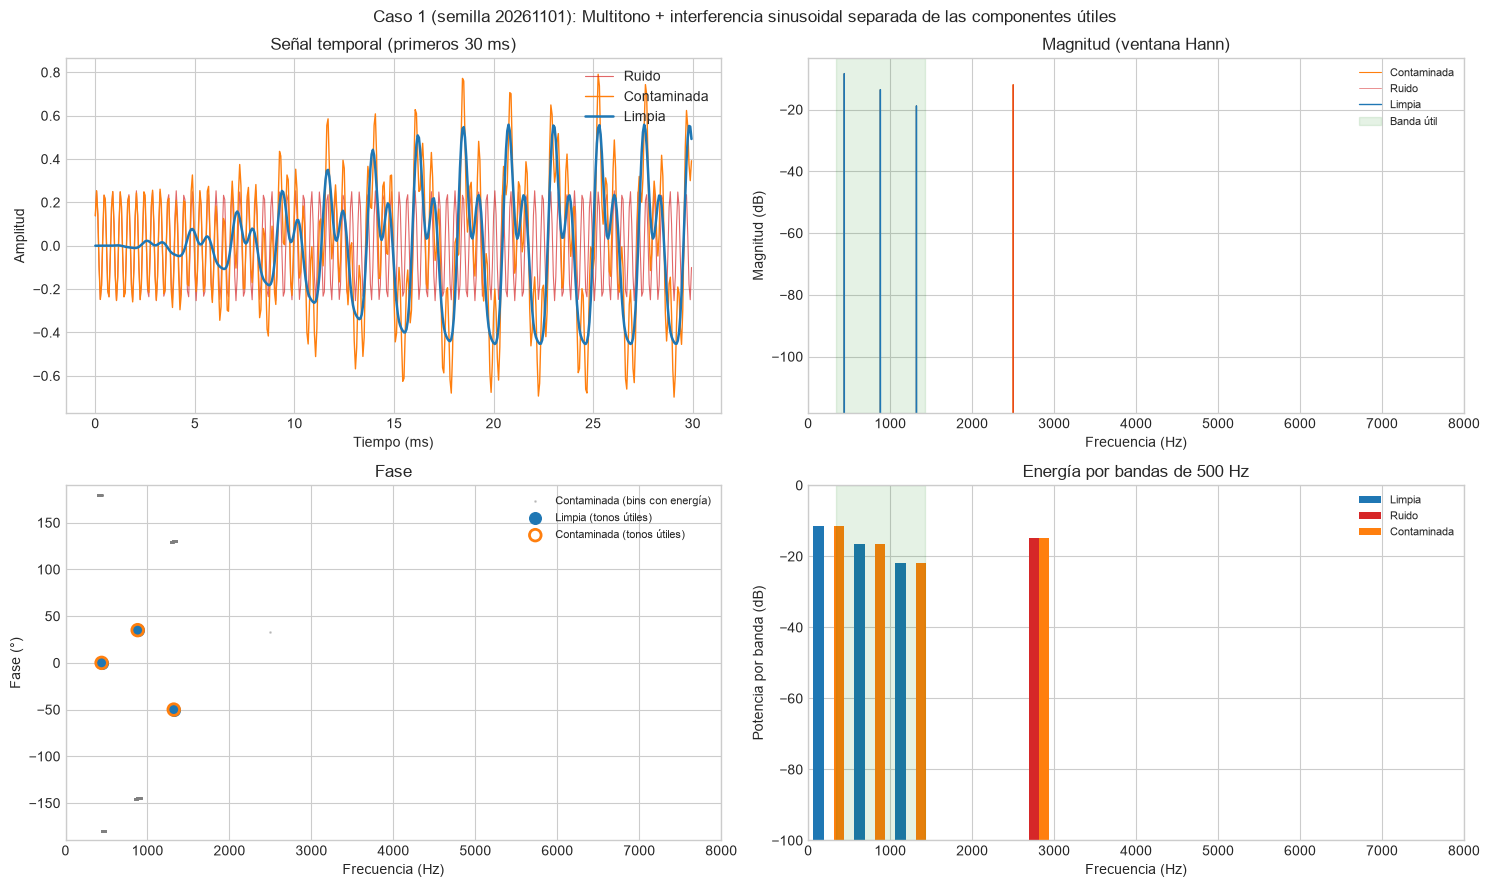

Caso 1: 0.0 % de la energía del ruido cae en la banda útil [340, 1420] Hz


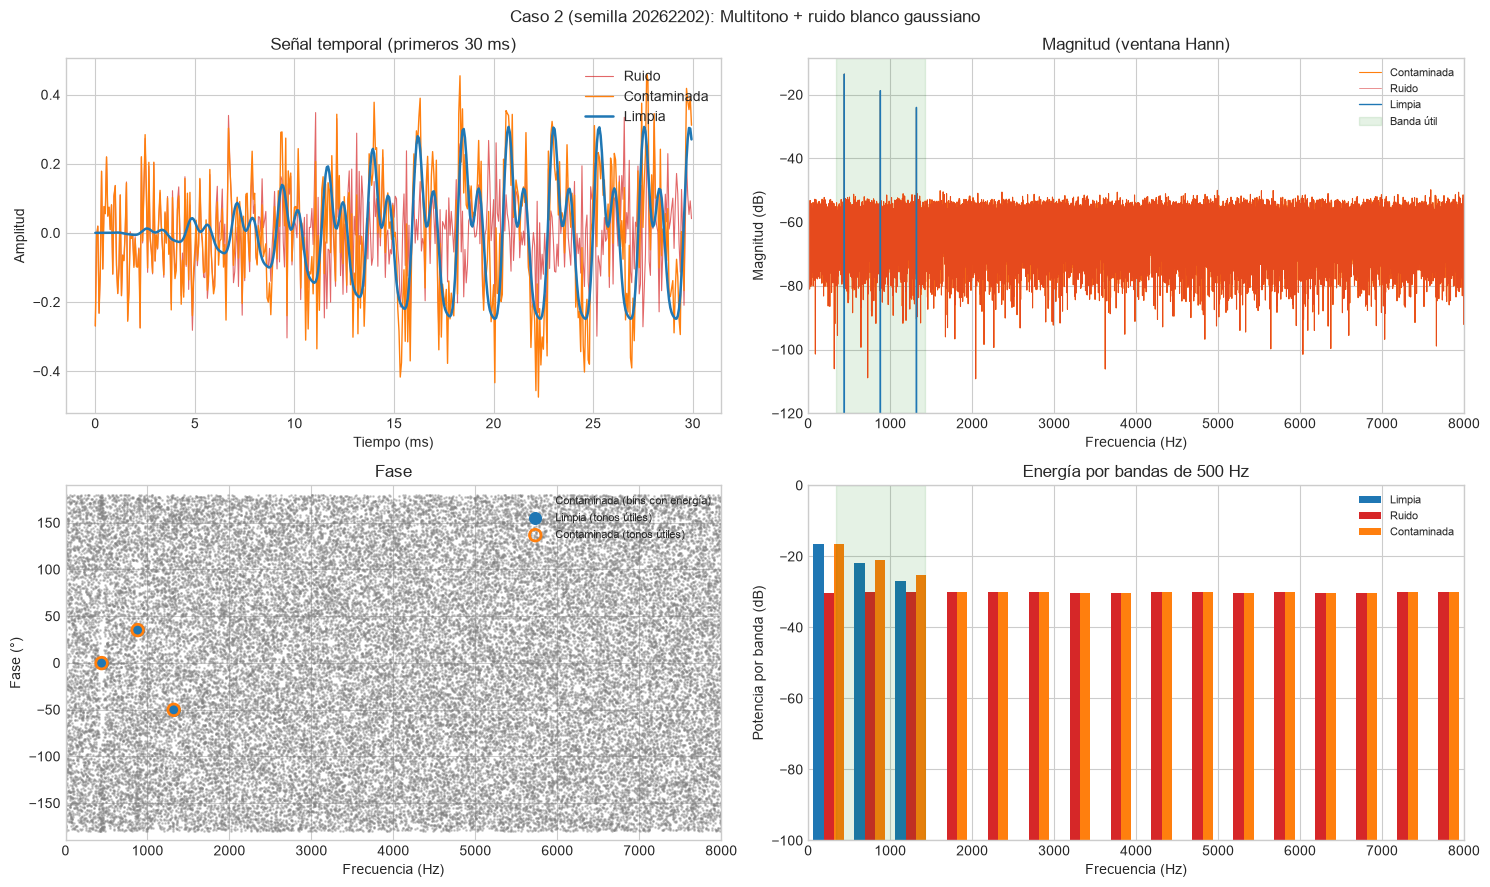

Caso 2: 13.5 % de la energía del ruido cae en la banda útil [340, 1420] Hz


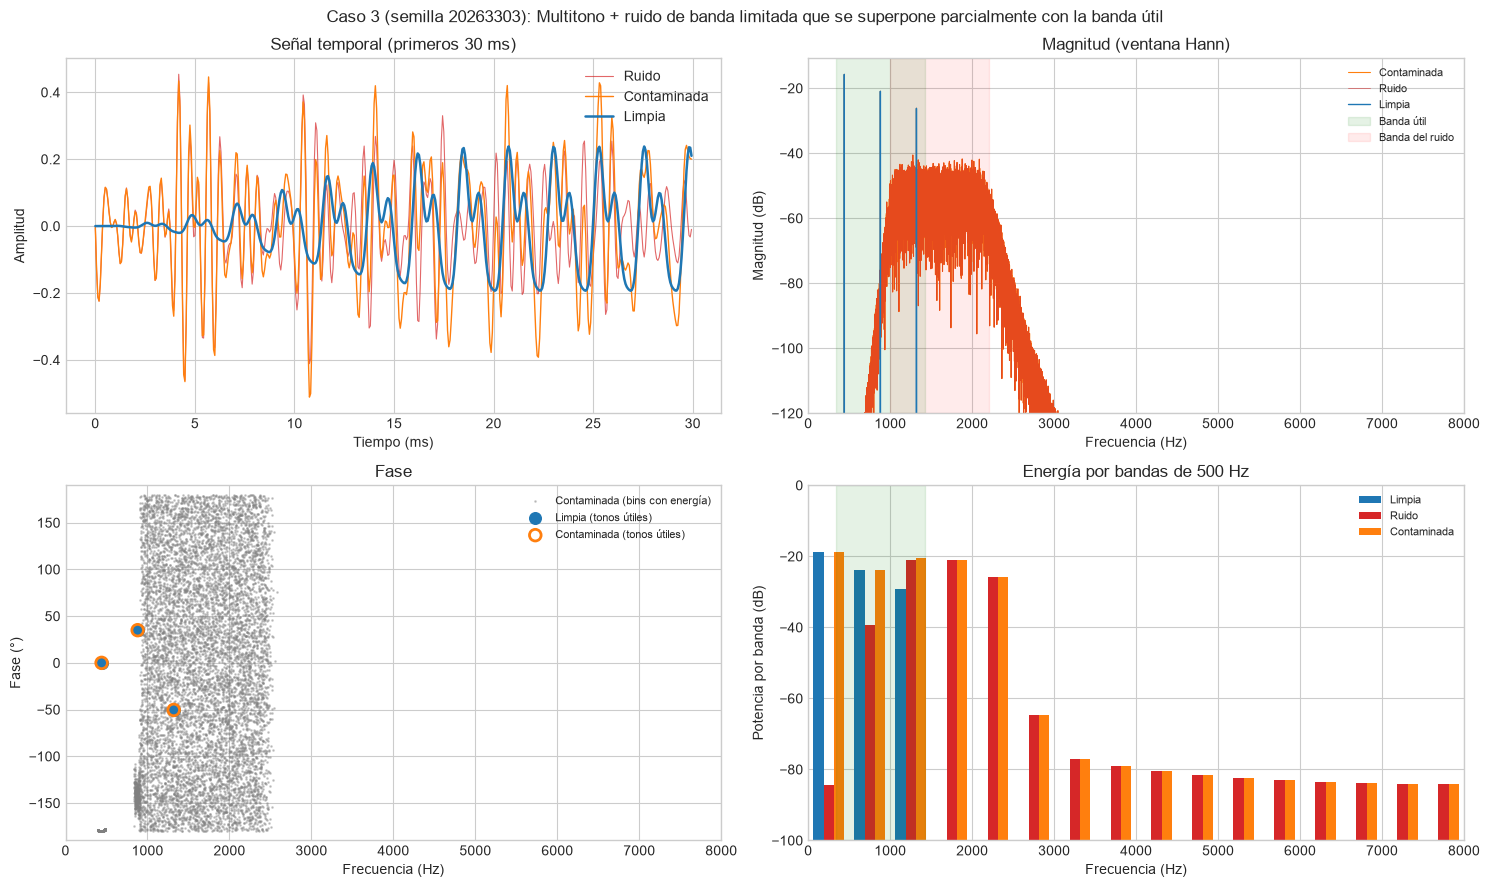

Caso 3: 35.1 % de la energía del ruido cae en la banda útil [340, 1420] Hz


In [8]:
for k, cfg in CASOS.items():
    d = DATOS[k]
    figura_caracterizacion(k, cfg, d)
    lo, hi = d['banda_util']
    RES[k]['frac_ruido_en_banda_util'] = potencia_en_rango(d['noise'], FS, lo, hi)/rms(d['noise'])**2
    print(f"Caso {k}: {100*RES[k]['frac_ruido_en_banda_util']:.1f} % de la energía del ruido cae en la banda útil [{lo}, {hi}] Hz")

## 7. Características para identificar automáticamente el ruido

| Descriptor | Interferencia tonal | Ruido blanco | Ruido de banda limitada |
|---|---|---|---|
| Planicidad espectral | ≈ 0 | ≈ 1 | ≈ 0 (plana solo dentro de la banda) |
| Cresta espectral | muy alta | baja | media |
| Ancho de banda del 99 % de la energía | muy angosto | ≈ fs/2 | ≈ ancho de la banda |
| Curtosis temporal | ≈ 1,5 | ≈ 3 | ≈ 3 |
| Autocorrelación (2–20 ms) | ≈ 1 | ≈ 0 | pequeña |

Los valores medidos sobre el ruido y la señal contaminada:

In [9]:
filas = []
for k, cfg in CASOS.items():
    for nombre, x in [('ruido', DATOS[k]['noise']), ('contaminada', DATOS[k]['noisy'])]:
        c = caracteristicas(x, FS)
        if nombre == 'ruido': RES[k]['car_ruido'] = c
        filas.append({'Caso': k, 'Tipo de ruido': cfg['tipo_ruido'], 'Señal': nombre, **c})
pd.DataFrame(filas).set_index(['Caso', 'Tipo de ruido', 'Señal']).round(3)

planicidad_espectral  cresta_espectral_dB  ancho_banda_99_Hz  curtosis  autocorr_max_2a20ms
Caso Tipo de ruido Señal                                                                                                   
1    tonal         ruido                       0.000               34.364              3.906     1.500                1.000
                   contaminada                 0.000               31.295           2064.453     2.230                0.995
2    blanco        ruido                       0.976                3.074           7917.969     2.996                0.010
                   contaminada                 0.330               30.730           7757.812     2.473                0.666
3    banda         ruido                       0.000               11.210           1244.141     3.025                0.043
                   contaminada                 0.000               29.490           1767.578     2.708                0.502

## 8. Qué no se puede recuperar cuando señal y ruido comparten frecuencias

En una frecuencia donde hay señal y ruido solo se observa la suma $Y(f)=S(f)+N(f)$, y existen infinitos pares $(S,N)$ con la misma suma: sin un modelo previo del ruido no es posible separarlos. Lo que no se recupera con exactitud en la banda compartida es:

* la **amplitud y la fase** de los componentes útiles (el ruido, de fase aleatoria, se suma vectorialmente al tono);
* la **forma de onda** de la señal en esa banda;
* los componentes útiles **más débiles que el ruido local**, que no se distinguen de una fluctuación del ruido.

La tabla cuantifica este efecto en cada tono con una ventana de ±5 Hz: la **SNR local** y el **error de fasor esperado** (calculado con la densidad local de ruido, no con una sola realización).

In [10]:
filas, n_bins = [], 2*ANCHO_LOCAL_HZ*DURACION + 1
for k, cfg in CASOS.items():
    d = DATOS[k]
    for f0, a0 in zip(cfg['frecuencias'], cfg['amplitudes']):
        ps = potencia_en_rango(d['clean'], FS, f0-ANCHO_LOCAL_HZ, f0+ANCHO_LOCAL_HZ)
        pn = potencia_en_rango(d['noise'], FS, f0-ANCHO_LOCAL_HZ, f0+ANCHO_LOCAL_HZ)
        filas.append({'Caso': k, 'f (Hz)': f0,
                      'SNR local (dB, tope 120)': min(10*np.log10(ps/max(pn, 1e-30)), 120.0),
                      'Error de fasor esperado (%)': 100*np.sqrt(2*pn/n_bins)/(a0*d['gain'])})
tabla_local = pd.DataFrame(filas).set_index(['Caso', 'f (Hz)'])
for k in CASOS:
    RES[k]['snr_local_min_dB'] = float(tabla_local.loc[k].iloc[:, 0].min())
    RES[k]['error_fasor_max_pct'] = float(tabla_local.loc[k].iloc[:, 1].max())
tabla_local.round(2)

SNR local (dB, tope 120)  Error de fasor esperado (%)
Caso f (Hz)                                                       
1    440                       120.00                         0.00
     880                       120.00                         0.00
     1320                      120.00                         0.00
2    440                        31.97                         0.32
     880                        25.48                         0.68
     1320                       20.32                         1.23
3    440                        79.56                         0.00
     880                        44.84                         0.07
     1320                        8.05                         5.05

Lectura: en el caso 1 el ruido no toca los tonos (recuperable en principio). En el caso 2 el ruido blanco está presente en todas las frecuencias con SNR local moderada. En el caso 3 el tono de 1320 Hz queda dentro de la banda del ruido: tiene la menor SNR local y el mayor error de fasor, y esa información no podría recuperarse con exactitud.

## 9. Reproducibilidad y guardado
Se regenera cada caso desde su semilla y se comprueba que es idéntico; luego se guardan `metadatos/configuraciones.json` y `resultados/metricas.csv`.

In [11]:
for k, cfg in CASOS.items():
    _, c2, n2, y2, g2 = generar_caso(cfg); d = DATOS[k]
    RES[k]['reproducible'] = bool(np.array_equal(c2, d['clean']) and np.array_equal(n2, d['noise']) and np.array_equal(y2, d['noisy']))
    assert RES[k]['reproducible']
print('Los tres casos se reproducen muestra a muestra con su semilla.')

NOMBRES_WAV = ['01_referencia_limpia.wav', '02_ruido.wav', '03_entrada_contaminada.wav']
config = {'grupo': GRUPO, 'seccion': '2.2', 'fs_Hz': FS, 'duracion_s': DURACION, 'pico_maximo': PICO_MAXIMO,
          'fade_ms': FADE_MS, 'tolerancia_snr_dB': TOL_SNR_DB, 'casos': {}}
for k, cfg in CASOS.items():
    d = DATOS[k]
    config['casos'][cfg['nombre']] = {
        'descripcion': cfg['descripcion'], 'semilla': int(cfg['semilla']), 'fs_Hz': int(FS), 'N': int(len(d['t'])),
        'duracion_s': float(len(d['t'])/FS), 'tipo_senal': cfg['tipo_senal'],
        'frecuencias_utiles_Hz': [float(v) for v in cfg['frecuencias']],
        'amplitudes_utiles': [float(v) for v in cfg['amplitudes']], 'fases_grados': [float(v) for v in cfg['fases']],
        'banda_util_Hz': [float(v) for v in d['banda_util']],
        'tipo_ruido': cfg['tipo_ruido'], 'detalle_ruido': cfg['detalle_ruido'],
        'frecuencia_interferencia_Hz': float(cfg['f_interferencia']) if cfg['tipo_ruido'] == 'tonal' else None,
        'banda_ruido_Hz': [float(v) for v in cfg['banda_ruido']] if cfg['tipo_ruido'] == 'banda' else None,
        'snr_objetivo_dB': float(cfg['snr_objetivo_db']), 'snr_obtenida_dB': float(RES[k]['snr_float_dB']),
        'snr_obtenida_wav_dB': float(RES[k]['snr_wav_dB']), 'ganancia_comun': float(d['gain']),
        'archivos': {n: {'ruta': (d['carpeta']/n).as_posix(), 'sha256': sha256(d['carpeta']/n)} for n in NOMBRES_WAV},
    }
with open(DIR_METADATOS/'configuraciones.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

filas = []
for k, cfg in CASOS.items():
    d, r = DATOS[k], RES[k]
    fila = {'caso': k, 'semilla': cfg['semilla'], 'fs_Hz': FS, 'N': len(d['t']), 'duracion_s': len(d['t'])/FS,
            'frecuencias_utiles_Hz': ';'.join(map(str, cfg['frecuencias'])), 'tipo_ruido': cfg['tipo_ruido'],
            'snr_objetivo_dB': cfg['snr_objetivo_db'], 'snr_float_dB': r['snr_float_dB'], 'snr_wav_dB': r['snr_wav_dB'],
            'dif_snr_wav_dB': r['snr_wav_dB'] - cfg['snr_objetivo_db'], 'snr_coincide': r['snr_ok'],
            'ganancia_comun': d['gain'], 'rms_limpia': rms(d['clean']), 'rms_ruido': rms(d['noise']),
            'rms_contaminada': rms(d['noisy']), 'frac_ruido_en_banda_util': r['frac_ruido_en_banda_util'],
            'snr_local_min_tono_dB': r['snr_local_min_dB'], 'error_fasor_max_pct': r['error_fasor_max_pct'],
            'reproducible': r['reproducible']}
    fila.update({f'ruido_{n}': v for n, v in r['car_ruido'].items()})
    filas.append(fila)
pd.DataFrame(filas).to_csv(DIR_RESULTADOS/'metricas.csv', index=False, encoding='utf-8')

print('Archivos generados:')
for p in sorted(RAIZ.rglob('*')):
    if p.is_file() and p.suffix in ('.wav', '.csv', '.json', '.png'):
        print(f'  {p.as_posix()}')

Los tres casos se reproducen muestra a muestra con su semilla.
Archivos generados:
  metadatos/configuraciones.json
  pruebas/caso_1/01_referencia_limpia.wav
  pruebas/caso_1/02_ruido.wav
  pruebas/caso_1/03_entrada_contaminada.wav
  pruebas/caso_2/01_referencia_limpia.wav
  pruebas/caso_2/02_ruido.wav
  pruebas/caso_2/03_entrada_contaminada.wav
  pruebas/caso_3/01_referencia_limpia.wav
  pruebas/caso_3/02_ruido.wav
  pruebas/caso_3/03_entrada_contaminada.wav
  resultados/figuras/caso_1_caracterizacion.png
  resultados/figuras/caso_2_caracterizacion.png
  resultados/figuras/caso_3_caracterizacion.png
  resultados/metricas.csv
